<a href="https://colab.research.google.com/github/richaa357/house_price_prediction/blob/main/House_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
df=pd.read_csv("/content/data.csv")

In [30]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [32]:
df.shape

(4600, 18)

In [33]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [34]:
df.isnull().sum()

,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0


In [35]:
df.duplicated().sum()

np.int64(0)

In [36]:
df.drop(["statezip","country","street"],axis=1,inplace=True)

In [37]:
df["date"].value_counts()

,count
date,
2014-06-23 00:00:00,142
2014-06-25 00:00:00,131
2014-06-26 00:00:00,131
2014-07-08 00:00:00,127
2014-07-09 00:00:00,121
...,...
2014-06-07 00:00:00,4
2014-07-06 00:00:00,3
2014-05-11 00:00:00,2


In [40]:
df["date"]=pd.to_datetime(df["date"])
df["month"]=df["date"].dt.month
df["month"].value_counts()


,count
month,
6,2179
5,1768
7,653


In [41]:
df["day"]=df["date"].dt.dayofweek
df["day"].value_counts()
df.drop("date",axis=1,inplace=True)


In [42]:
df["city"].unique()


array(['Shoreline', 'Seattle', 'Kent', 'Bellevue', 'Redmond',
       'Maple Valley', 'North Bend', 'Lake Forest Park', 'Sammamish',
       'Auburn', 'Des Moines', 'Bothell', 'Federal Way', 'Kirkland',
       'Issaquah', 'Woodinville', 'Normandy Park', 'Fall City', 'Renton',
       'Carnation', 'Snoqualmie', 'Duvall', 'Burien', 'Covington',
       'Inglewood-Finn Hill', 'Kenmore', 'Newcastle', 'Mercer Island',
       'Black Diamond', 'Ravensdale', 'Clyde Hill', 'Algona', 'Skykomish',
       'Tukwila', 'Vashon', 'Yarrow Point', 'SeaTac', 'Medina',
       'Enumclaw', 'Snoqualmie Pass', 'Pacific', 'Beaux Arts Village',
       'Preston', 'Milton'], dtype=object)

In [43]:
df.drop("city",axis=1,inplace=True)

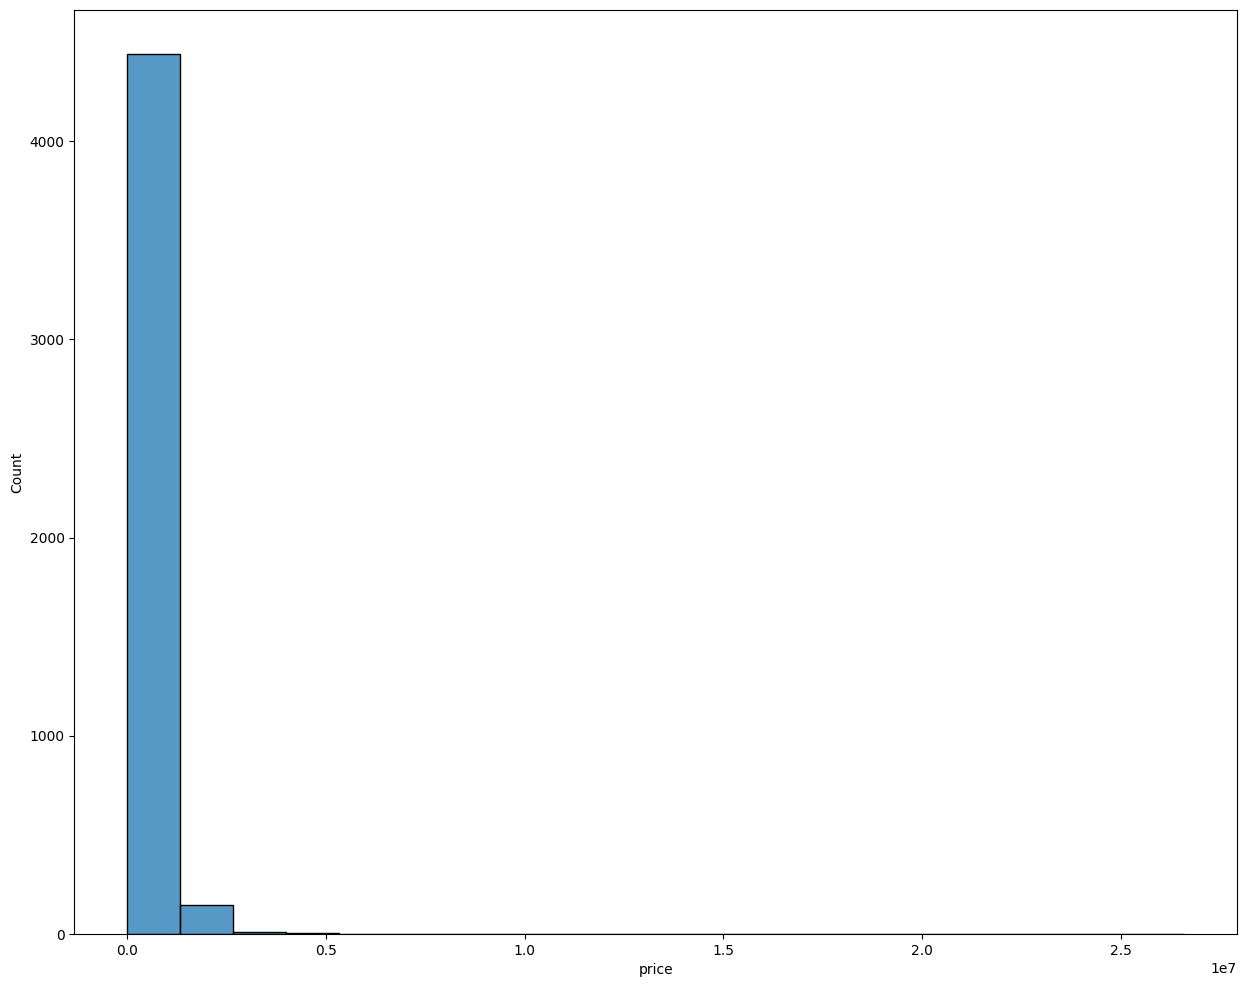

In [47]:
plt.figure(figsize=(15,12))
sns.histplot(df["price"],bins=20)
plt.show()

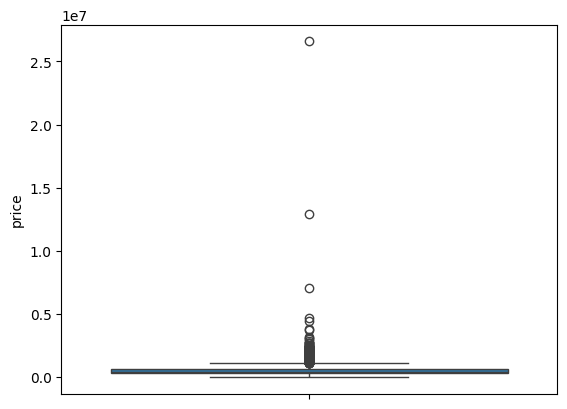

In [48]:
sns.boxplot(df["price"])
plt.show()

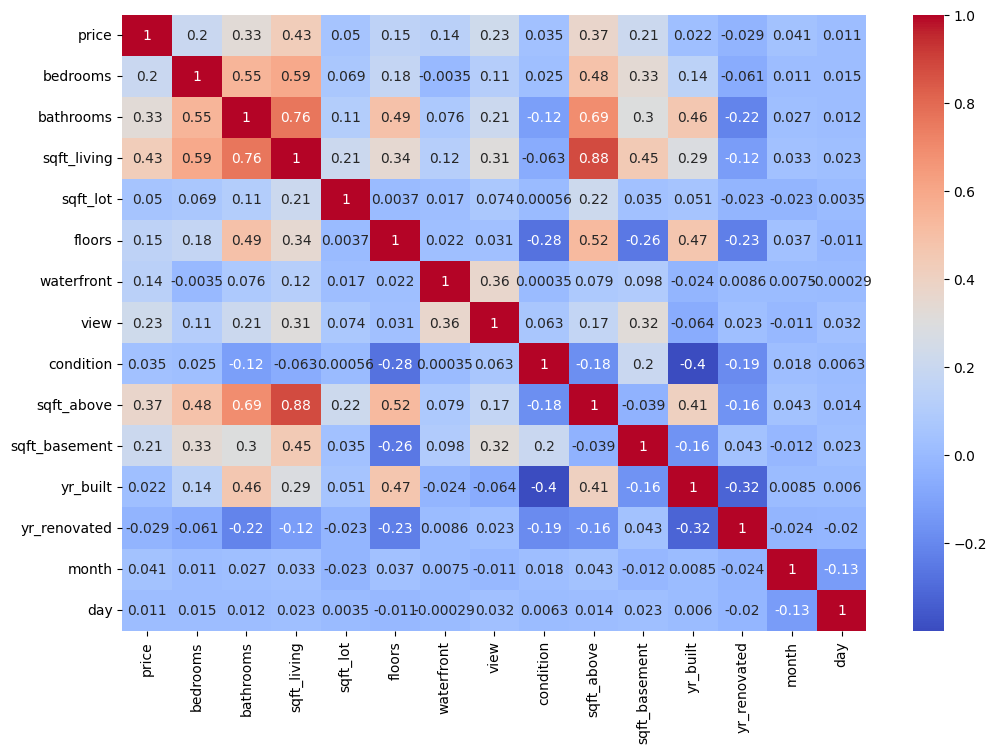

In [49]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.show()

In [50]:
X=df.drop(["price"],axis=1)
Y=df["price"]
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,Y_train)
print(model.coef_)
print(model.intercept_)

[-6.44140205e+04  3.66014849e+04  1.85854064e+02 -5.12271059e-01
  6.97673341e+04  3.82100904e+05  4.48873047e+04  2.92120922e+04
  9.67108229e+01  8.91432411e+01 -2.56878099e+03  8.31039858e+00
  4.82186643e+03  3.51431402e+02]
4897039.5369669385


In [51]:
Y_pred=model.predict(X_test)
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mae=mean_absolute_error(Y_test,Y_pred)
print(mae)
mse=mean_squared_error(Y_test,Y_pred)
print(mse)
rmse=np.sqrt(mse)
print(rmse)
r2=r2_score(Y_test,Y_pred)
print(r2)

211031.2274858895
986567294218.1481
993260.9396418184
0.03263143138403479


In [52]:
comparison=pd.DataFrame({"Actual" : Y_test,"Predicted" : Y_pred})
print(comparison.head())

         Actual     Predicted
3683   544000.0  3.054594e+05
4411        0.0  3.232886e+05
2584  1712500.0  1.072242e+06
69     365000.0  5.437203e+05
1844   275000.0  3.812198e+05


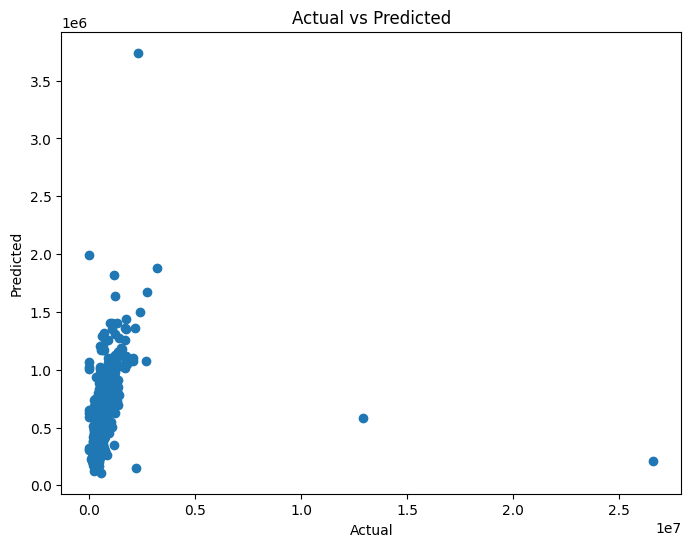

In [53]:
plt.figure(figsize=(8,6))
plt.scatter(Y_test,Y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()